# Exercise 1

We first load a dataset and examine its dimensions.

In [1]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import math
import numpy as np

xy_data = np.load('Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)

(70, 2)

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

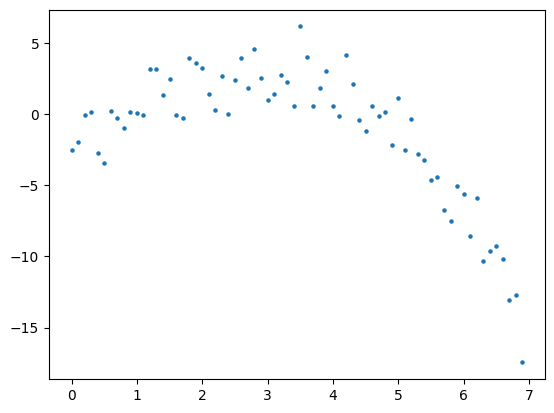

In [83]:
import matplotlib.pyplot as plt
# Your code for scatterplot here

# Scatter plot and quadratic fit
plt.scatter(xy_data[:,0], xy_data[:,1],s=5)

plt.show()



### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset. 
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals. 

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [84]:
def polyreg(data_matrix, k):
    yvalues = data_matrix[:,1]
    xvalues = data_matrix[:,0]
    N = len(xvalues)
    X = np.ones((N, 1))
    for i in range(k) :
        X = np.column_stack((X, xvalues**(i+1) ))
    XT = X.T
    beta = np.linalg.inv(XT.dot(X)).dot(XT).dot(yvalues)
    for i in range(N-k-1) :
        np.append(beta,0)
    fit =  X.dot(beta)
    R = yvalues-fit
    return [beta, fit , R]
    # Your code here
    # The function should return the the coefficient vector beta, the fit, and the vector of residuals
    

Use the tests below to check the outputs of the function you have written:

In [85]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0] 
print(beta_test)
assert((np.round(beta_test[0], 3) == 2) and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))  
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

[ 2. -7.  3.]


### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included. 
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

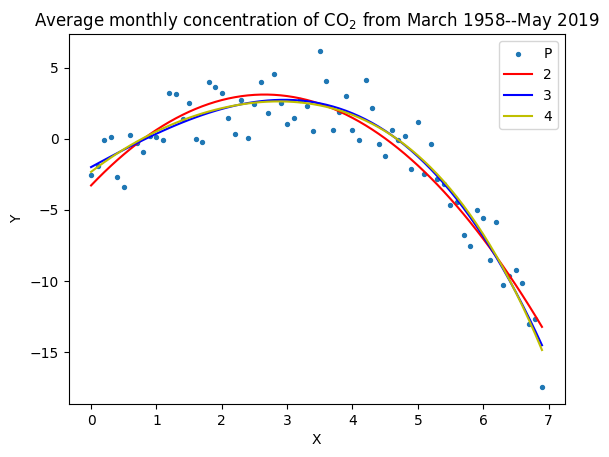

SSE for different k [172.18102528988555, 152.40580488915808, 151.22778969027115]
R:  [0.8876297774918223, 0.9005356474205022, 0.9013044535638857]
We can use k=4 for the biggest R. However, since the numbers are close for 3 and 4, we need to use test and train data method to see which method is the best to be used, k=3 is close enough and it is much faster to proccess So I chose k as 3


In [112]:
import matplotlib.pyplot as plt

plt.scatter(xy_data[:,0], xy_data[:,1],s=8)
k_2 = polyreg(xy_data, k=2)
k_3=polyreg(xy_data, k=3)
k_4=polyreg(xy_data, k=4)
plt.plot(xy_data[:,0], k_2[1], 'r')
plt.plot(xy_data[:,0], k_3[1], 'b')
plt.plot(xy_data[:,0], k_4[1], 'y')
plt.legend("P234")
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Average monthly concentration of CO$_2$ from March 1958--May 2019')
plt.show()
SSEs = [np.sum((k_2)[2]**2),np.sum((k_3)[2]**2),np.sum((k_4)[2]**2)]
print("SSE for different k",SSEs)
SSe=np.sum((polyreg(xy_data, k=0))[2]**2 )
R = [1-SSEs[0]/SSe,1-SSEs[1]/SSe, 1-SSEs[2]/SSe]
print("R: ",R)
print("We can use k=4 for the biggest R. However, since the numbers are close for 3 and 4, we need to use test and train data method to see which method "
"is the best to be used, k=3 is close enough and it is much faster to proccess So I chose k as 3")



 #### State which model you choose and briefly justify your choice.
 
 
 < fill in your answer in this cell.>
 
 

### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot. 
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

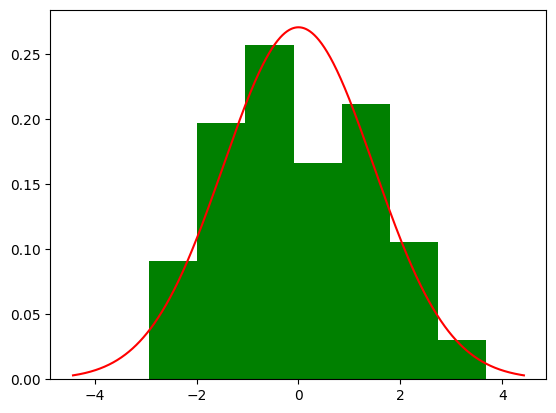

In [118]:
#Your code here
from scipy.stats import norm

res_final_stdev = np.std(k_3[2]) 
xvals = np.linspace(-3*res_final_stdev,3*res_final_stdev,1000)
n, bins, patches = plt.hist(k_3[2], bins=7, density=True, facecolor='green')
plt.plot(xvals, norm.pdf(xvals, loc=0, scale=res_final_stdev), 'r')
plt.plot

